In [1]:
from pathlib import Path
import json
import re
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# 0. Paths
# =========================

OUTPUT_DIR = Path("../results/phase2_qwen/humaneval/code_then_plan")
ANALYSIS_DIR = OUTPUT_DIR / "analysis_reports"
FIG_DIR = ANALYSIS_DIR / "figures"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

STEP_LOG_PATH = OUTPUT_DIR / "step_logs.jsonl"
TRAJ_LOG_PATH = OUTPUT_DIR / "trajectory_logs.jsonl"
SUMMARY_PATH = OUTPUT_DIR / "summary.json"


# =========================
# 1. Load JSONL
# =========================

def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


step_rows = load_jsonl(STEP_LOG_PATH)
traj_rows = load_jsonl(TRAJ_LOG_PATH)

step_df = pd.DataFrame(step_rows)
traj_df = pd.DataFrame(traj_rows)

print("step_df shape:", step_df.shape)
print("traj_df shape:", traj_df.shape)
print("step columns:", step_df.columns.tolist())
print("traj columns:", traj_df.columns.tolist())

step_df shape: (472, 36)
traj_df shape: (164, 24)
step columns: ['run_id', 'dataset', 'problem_id', 'method', 'trajectory_id', 'step_id', 'call_index', 'candidate_id', 'stage', 'is_retry', 'is_repair', 'is_planner', 'policy_action', 'input_tokens', 'output_tokens', 'total_tokens', 'latency_sec', 'avg_entropy', 'max_entropy', 'entropy_std', 'first_20pct_entropy', 'last_20pct_entropy', 'code', 'planner_output', 'exec_ok', 'test_pass', 'status', 'error_type', 'error_stage', 'error_message', 'tests_passed', 'tests_total', 'code_length', 'selected', 'selection_rank', 'entry_point']
traj columns: ['run_id', 'dataset', 'problem_id', 'method', 'trajectory_id', 'num_steps', 'call_count', 'final_status', 'failure_family', 'final_tests_passed', 'final_tests_total', 'total_input_tokens', 'total_output_tokens', 'total_tokens', 'total_latency', 'num_exec_fail', 'num_test_fail', 'transition_path', 'used_plan', 'entropy_series', 'initial_avg_entropy', 'budget_used', 'recovered_by', 'plan_recovery_atte

In [2]:
# =========================
# 2. Basic preprocessing for your log schema
# =========================

PROBLEM_COL = "problem_id"
STEP_COL = "step_id"
SUCCESS_COL = "test_pass"
ENTROPY_COL = "avg_entropy"
ERROR_TYPE_COL = "error_type"
ERROR_MSG_COL = "error_message"

step_df["success_bool"] = step_df[SUCCESS_COL].astype(bool)
step_df["step_num"] = pd.to_numeric(step_df[STEP_COL], errors="coerce")
step_df["entropy_value"] = pd.to_numeric(step_df[ENTROPY_COL], errors="coerce")

step_df["error_type_norm"] = step_df[ERROR_TYPE_COL].fillna("no_error_or_unknown")
step_df["error_message_norm"] = step_df[ERROR_MSG_COL].fillna("")

# final outcome from trajectory log
traj_df["final_success"] = traj_df["final_status"] == "PASS"
traj_df["used_repair"] = traj_df["num_steps"] > 1

print(step_df[[
    "problem_id", "step_id", "stage", "is_repair",
    "avg_entropy", "error_type", "status", "test_pass"
]].head())

print(traj_df[[
    "problem_id", "num_steps", "call_count",
    "final_status", "failure_family", "initial_avg_entropy"
]].head())

    problem_id  step_id     stage  is_repair  avg_entropy error_type status  \
0  HumanEval/0        0  generate      False     0.127636       None   PASS   
1  HumanEval/1        0  generate      False     0.250144       None   PASS   
2  HumanEval/2        0  generate      False     0.184339       None   PASS   
3  HumanEval/3        0  generate      False     0.119799       None   PASS   
4  HumanEval/4        0  generate      False     0.206295       None   PASS   

  test_pass  
0      True  
1      True  
2      True  
3      True  
4      True  
    problem_id  num_steps  call_count final_status failure_family  \
0  HumanEval/0          1           1         PASS           PASS   
1  HumanEval/1          1           1         PASS           PASS   
2  HumanEval/2          1           1         PASS           PASS   
3  HumanEval/3          1           1         PASS           PASS   
4  HumanEval/4          1           1         PASS           PASS   

   initial_avg_entropy  
0

In [3]:
# =========================
# 3. Overall repair-only trajectory summary
# =========================

num_problems = len(traj_df)
num_solved = traj_df["final_success"].sum()

num_one_shot_success = (
    (traj_df["final_success"]) &
    (traj_df["num_steps"] == 1)
).sum()

num_used_repair = traj_df["used_repair"].sum()

num_repair_solved = (
    traj_df["used_repair"] &
    traj_df["final_success"]
).sum()

summary = {
    "num_problems": int(num_problems),
    "num_solved": int(num_solved),
    "overall_success_rate": float(num_solved / num_problems),
    "num_one_shot_success": int(num_one_shot_success),
    "one_shot_success_rate": float(num_one_shot_success / num_problems),
    "num_used_repair": int(num_used_repair),
    "repair_used_rate": float(num_used_repair / num_problems),
    "num_repair_solved": int(num_repair_solved),
    "repair_success_rate_among_repair_used": float(num_repair_solved / num_used_repair) if num_used_repair else None,
    "mean_steps_all": float(traj_df["num_steps"].mean()),
    "mean_steps_solved": float(traj_df.loc[traj_df["final_success"], "num_steps"].mean()),
    "mean_steps_repair_solved": float(
        traj_df.loc[traj_df["used_repair"] & traj_df["final_success"], "num_steps"].mean()
    ),
    "median_steps_repair_solved": float(
        traj_df.loc[traj_df["used_repair"] & traj_df["final_success"], "num_steps"].median()
    ),
}

summary

{'num_problems': 164,
 'num_solved': 152,
 'overall_success_rate': 0.926829268292683,
 'num_one_shot_success': 115,
 'one_shot_success_rate': 0.7012195121951219,
 'num_used_repair': 49,
 'repair_used_rate': 0.29878048780487804,
 'num_repair_solved': 37,
 'repair_success_rate_among_repair_used': 0.7551020408163265,
 'mean_steps_all': 2.8780487804878048,
 'mean_steps_solved': 1.605263157894737,
 'mean_steps_repair_solved': 3.4864864864864864,
 'median_steps_repair_solved': 3.0}

In [4]:
# =========================
# 4. Figure directory
# =========================

FIG_DIR = ANALYSIS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("FIG_DIR:", FIG_DIR)

FIG_DIR: ../results/phase2_qwen/humaneval/code_then_plan/analysis_reports/figures


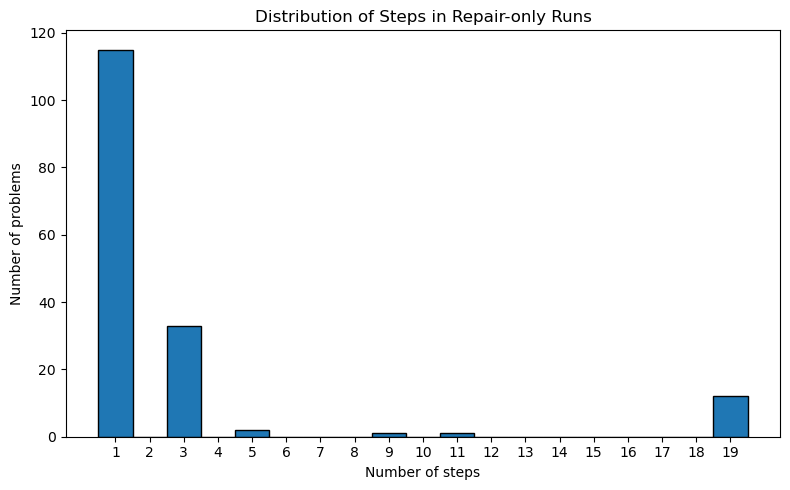

In [5]:
# =========================
# Figure 1. Distribution of num_steps
# 문제 하나를 해결하기 까지 걸린 총 시도 횟수
# 1 = 첫 시도에서 바로 성공
# 2 이상부터 repair 사용
# =========================

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

max_step = int(traj_df["num_steps"].max())

plt.hist(
    traj_df["num_steps"],
    bins=range(1, max_step + 2),
    edgecolor="black",
    align="left"
)

plt.xticks(range(1, max_step + 1))  # ← 핵심
plt.xlabel("Number of steps")
plt.ylabel("Number of problems")
plt.title("Distribution of Steps in Repair-only Runs")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_num_steps_distribution.png", dpi=300)
plt.show()

In [6]:
# =========================
# Table 1: Step distribution
# =========================

step_dist = traj_df["num_steps"].value_counts().sort_index().reset_index()
step_dist.columns = ["num_steps", "count"]

step_dist["ratio"] = step_dist["count"] / step_dist["count"].sum()

step_dist

,num_steps,count,ratio
0,1,115,0.701220
1,3,33,0.201220
2,5,2,0.012195
3,9,1,0.006098
4,11,1,0.006098
5,19,12,0.073171


In [7]:
# =========================
# Table 3: Success rate by repair depth
# =========================

depth_table = (
    traj_df.groupby("num_steps")["final_success"]
    .agg(["count", "mean"])
    .reset_index()
)

depth_table.columns = ["num_steps", "num_problems", "success_rate"]

depth_table

,num_steps,num_problems,success_rate
0,1,115,1.0
1,3,33,1.0
2,5,2,1.0
3,9,1,1.0
4,11,1,1.0
5,19,12,0.0


---

In [8]:
df = step_df.copy()

df = df[df["stage"].isin(["generate", "plan",])].copy()

df = df.sort_values(["problem_id", "call_index"])

# PASS 여부 (trajectory 기준)
traj_success = (
    traj_df.set_index("problem_id")["final_status"] == "PASS"
)

df["traj_success"] = df["problem_id"].map(traj_success)

In [9]:
traj_entropy = {}

for pid, group in df.groupby("problem_id"):
    group = group.sort_values("call_index")
    ent = group["avg_entropy"].tolist()
    traj_entropy[pid] = ent

In [10]:
success_traj = []
fail_traj = []

for pid, ent_list in traj_entropy.items():
    if traj_success.get(pid, False):
        success_traj.append(ent_list)
    else:
        fail_traj.append(ent_list)

/tmp/ipykernel_2357692/1093265747.py:14: RuntimeWarning: Mean of empty slice
  success_mean = np.nanmean(success_arr, axis=0)


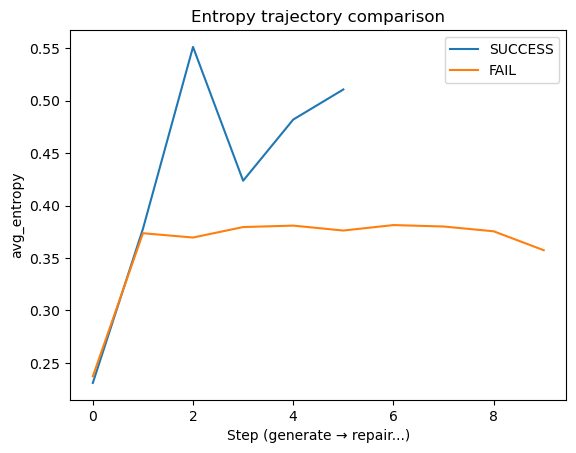

In [11]:
def pad_and_stack(trajs, max_len=10):
    arr = []
    for t in trajs:
        if len(t) < max_len:
            t = t + [np.nan] * (max_len - len(t))
        else:
            t = t[:max_len]
        arr.append(t)
    return np.array(arr)

success_arr = pad_and_stack(success_traj)
fail_arr = pad_and_stack(fail_traj)

success_mean = np.nanmean(success_arr, axis=0)
fail_mean = np.nanmean(fail_arr, axis=0)

plt.plot(success_mean, label="SUCCESS")
plt.plot(fail_mean, label="FAIL")
plt.xlabel("Step (generate → repair...)")
plt.ylabel("avg_entropy")
plt.legend()
plt.title("Entropy trajectory comparison")
plt.savefig(FIG_DIR / "entropy_trajectory.png")
plt.show()

/tmp/ipykernel_2357692/2816391553.py:20: RuntimeWarning: Mean of empty slice
  success_mean = np.nanmean(success_arr, axis=0)
/home/dibaeck/miniconda3/envs/amla/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


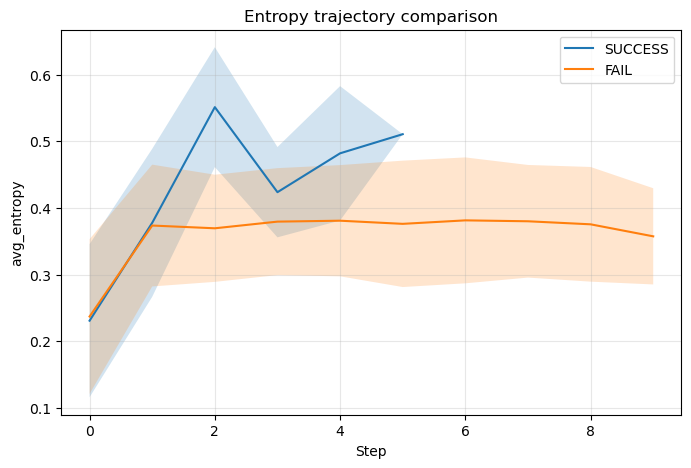

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def pad_and_stack(trajs, max_len=10):
    arr = []
    for t in trajs:
        t = list(t)
        if len(t) < max_len:
            t = t + [np.nan] * (max_len - len(t))
        else:
            t = t[:max_len]
        arr.append(t)
    return np.array(arr)

MAX_LEN = 10

success_arr = pad_and_stack(success_traj, MAX_LEN)
fail_arr = pad_and_stack(fail_traj, MAX_LEN)

success_mean = np.nanmean(success_arr, axis=0)
fail_mean = np.nanmean(fail_arr, axis=0)

success_std = np.nanstd(success_arr, axis=0)
fail_std = np.nanstd(fail_arr, axis=0)

x = np.arange(MAX_LEN)

plt.figure(figsize=(8, 5))
plt.plot(x, success_mean, label="SUCCESS")
plt.fill_between(x, success_mean - success_std, success_mean + success_std, alpha=0.2)

plt.plot(x, fail_mean, label="FAIL")
plt.fill_between(x, fail_mean - fail_std, fail_mean + fail_std, alpha=0.2)

plt.xlabel("Step")
plt.ylabel("avg_entropy")
plt.title("Entropy trajectory comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
print("num success traj:", len(success_traj))
print("num fail traj:", len(fail_traj))

print("success mean:", success_mean)
print("fail mean:", fail_mean)
print("diff fail-success:", fail_mean - success_mean)

num success traj: 152
num fail traj: 12
success mean: [0.230832   0.37767603 0.55123479 0.42363647 0.48195996 0.51065388
        nan        nan        nan        nan]
fail mean: [0.23710245 0.37358449 0.36946616 0.37946533 0.38084659 0.37613501
 0.38135482 0.37998986 0.37543244 0.35739074]
diff fail-success: [ 0.00627044 -0.00409154 -0.18176862 -0.04417114 -0.10111337 -0.13451887
         nan         nan         nan         nan]


In [14]:
def compute_delta(trajs):
    deltas = []
    for t in trajs:
        if len(t) >= 2:
            deltas.append(t[-1] - t[0])
    return np.array(deltas)

success_delta = compute_delta(success_traj)
fail_delta = compute_delta(fail_traj)

print("SUCCESS Δentropy mean:", np.mean(success_delta))
print("FAIL Δentropy mean:", np.mean(fail_delta))

SUCCESS Δentropy mean: 0.13461847687209452
FAIL Δentropy mean: 0.12028829390817042


In [15]:
success_last = [t[-1] for t in success_traj]
fail_last = [t[-1] for t in fail_traj]

print(np.mean(success_last), np.mean(fail_last))

0.26360097529742593 0.35739073906685365
